In [1]:
# Carga de paquetes necesarios para graficar
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd # Para leer archivos
import geopandas as gpd # Para hacer cosas geográficas
import seaborn as sns # Para hacer plots lindos
import networkx as nx # Construcción de la red en NetworkX
import scipy

Funciones para Colab

In [2]:
# Importamos las funciones del template
from template_funciones import *

# Preambulo

En esta sección cargamos los datos y los visualizamos. También construimos la matriz de adyacencia de la red de museos.

## Carga de datos de los museos

El listado de los museos, con el que se construye el [mapa](https://mapas.museosabiertos.org/museos/caba/), lo podemos encontrar [acá](https://github.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/blob/principal/data/export.geojson?short_path=bc357f3). También descargamos los barrios de CABA como complemento para los gráficos.

In [3]:
# Leemos el archivo, retenemos aquellos museos que están en CABA, y descartamos aquellos que no tienen latitud y longitud
museos = gpd.read_file('https://raw.githubusercontent.com/MuseosAbiertos/Leaflet-museums-OpenStreetMap/refs/heads/principal/data/export.geojson')
barrios = gpd.read_file('https://cdn.buenosaires.gob.ar/datosabiertos/datasets/ministerio-de-educacion/barrios/barrios.geojson')

## Visualización

<Axes: >

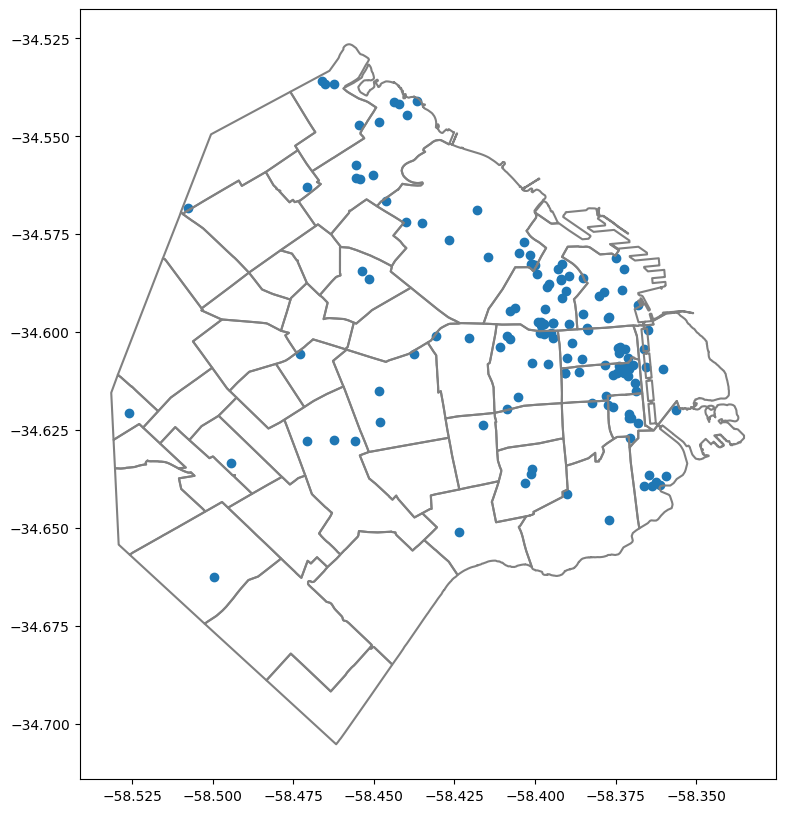

In [4]:
# Armamos el gráfico para visualizar los museos
fig, ax = plt.subplots(figsize=(10, 10))
barrios.boundary.plot(color='gray',ax=ax)
museos.plot(ax=ax)

## Cálculo de la matriz de distancias

Ahora construimos la matriz de distancias entre todos los museos. Como la tierra es un [geoide](https://es.wikipedia.org/wiki/Geoide) (es decir que no es [plana](https://es.wikipedia.org/wiki/Terraplanismo)), el cálculo de distancias no es una operación obvia. Una opción es proyectar a un [sistema de coordenadas local](https://geopandas.org/en/stable/docs/user_guide/projections.html), de forma tal que las distancias euclideas se correspondan con las distancias en metros. En este notebook usamos [EPSG](https://en.wikipedia.org/wiki/EPSG_Geodetic_Parameter_Dataset) 22184.

In [5]:
# En esta línea:
# Tomamos museos, lo convertimos al sistema de coordenadas de interés, extraemos su geometría (los puntos del mapa),
# calculamos sus distancias a los otros puntos de df, redondeamos (obteniendo distancia en metros), y lo convertimos a un array 2D de numpy
D = museos.to_crs("EPSG:22184").geometry.apply(lambda g: museos.to_crs("EPSG:22184").distance(g)).round().to_numpy()

### Matriz de adyacencia: construimos una matriz conectando a cada museo con los $m$ más cercanos

In [6]:
def construye_adyacencia(D,m):
    # Función que construye la matriz de adyacencia del grafo de museos
    # D matriz de distancias, m cantidad de links por nodo
    # Retorna la matriz de adyacencia como un numpy.
    D = D.copy()
    l = [] # Lista para guardar las filas
    for fila in D: # recorriendo las filas, anexamos vectores lógicos
        l.append(fila<=fila[np.argsort(fila)[m]] ) # En realidad, elegimos todos los nodos que estén a una distancia menor o igual a la del m-esimo más cercano
    A = np.asarray(l).astype(int) # Convertimos a entero
    np.fill_diagonal(A,0) # Borramos diagonal para eliminar autolinks
    return(A)

m = 3 # Cantidad de links por nodo
A = construye_adyacencia(D,m)

## Construcción de la red en NetworkX (sólo para las visualizaciones)

In [7]:
G = nx.from_numpy_array(A) # Construimos la red a partir de la matriz de adyacencia
# Construimos un layout a partir de las coordenadas geográficas
G_layout = {i:v for i,v in enumerate(zip(museos.to_crs("EPSG:22184").get_coordinates()['x'],museos.to_crs("EPSG:22184").get_coordinates()['y']))}

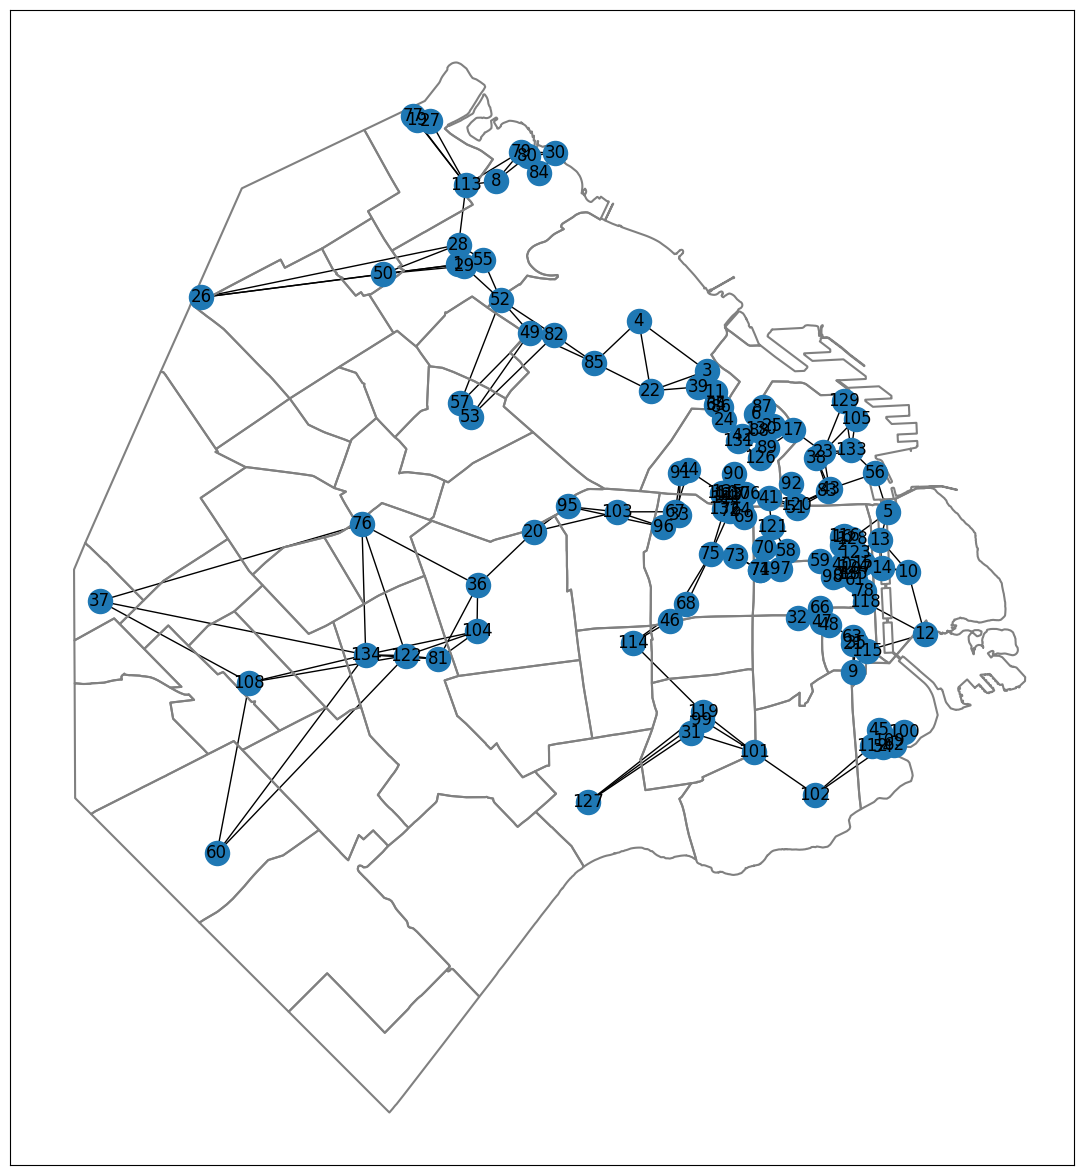

In [8]:
fig, ax = plt.subplots(figsize=(15, 15)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
nx.draw_networkx(G,G_layout,ax=ax) # Graficamos los museos

# Resolución del TP

Aquí empieza la aventura... ¡diviertanse y consulten lo que necesiten!

## Punto 1:

Sabemos que nuestra definicion de p es
\begin{align}
      p = (1-\alpha).Cp+\frac{\alpha}{N} \vec{1}
\end{align}

Ahora despejomos nuestra definicion de P para llegar a lo pedido

\begin{align}
      p - (1-\alpha).Cp &= \frac{\alpha}{N} \vec{1} \\
      (I-(1-\alpha).C)p &= \frac{\alpha}{N} \vec{1} \\
      \frac{N}{\alpha}(I-(1-\alpha).C)p &= \vec{1}
\end{align}

Podemos ver como finalmente nos queda $\vec1$ es el $b$ y queda $\frac{N}{\alpha}(I-(1-\alpha).C)$ como $M$

## Punto 2:


Para que la ecuacion definida en el punto anterior tenga una unica solucion, se debe cumplir que $M$ sea inversible, pues $Mp = b \Rightarrow p = M^{-1}b \rightarrow p$ es unico

Recordemos que $M = \frac{N}{\alpha}(I-(1-\alpha).C)$ y sabemos lo siguiente:
1.   $||C||_1 = 1$
2.   Por enunciado, sabemos $0 < \alpha <1 $

Ahora con todo lo anterior, supongamos la matriz $\lambda C$ tal que $\lambda \in \mathbb{R}, 0 < \lambda < 1$. Aplicando la norma uno quedaria

\begin{align}
  ||\lambda C|| = \lambda ||C|| \leq \lambda < 1 \Rightarrow ||\lambda C|| < 1, \forall 0 < \lambda < 1  
\end{align}

Volviendo a nuestra matriz $M$, observemos que como $\alpha \in (0,1) \Rightarrow 0<1-\alpha<1$. Llamemos $\lambda = 1 - \alpha$ Para que $M$ sea inversible, basta probar que $I - \lambda C$ lo es, pues $\frac{N}{\alpha}$ es escalar, y no afecta a la inversibilidad

Supongamos que no es inversible.
Luego,
$\exists \vec{v} \neq \vec{0} : (I - \lambda C). \vec{v} = 0 \Leftrightarrow \vec{v} - \lambda C . \vec{v} = 0 \Leftrightarrow \vec{v} = \lambda C . \vec{v}$

Ahora tomemos norma de ambos lados

$||\vec{v}||_1 = ||\lambda C.\vec{v}||_1 \leq ||\lambda C||_1 ||\vec{v}||_1  \quad \underline{OBS} \; \vec{v} \neq 0 \Rightarrow ||\vec{v}||_1 \neq 0$

$\Leftrightarrow \frac{||\vec{v}||_1}{||\vec{v}||_1} \leq ||\lambda C||_1 . \frac{||\vec{v}||_1}{||\vec{v}||_1} \Leftrightarrow 1 \leq ||\lambda C||_1 \rightarrow \underline{ABS!}$

Ya que por nuestra hipotesis sabemos que $||\lambda C||_1 < 1$

Luego $I-\lambda C = I - (1 - \alpha).C$ es inversible $\Rightarrow M$ inversible


## Punto 3:

### Calculo base de Page Rank

Vamos a hacer nuestro caso base el cual son los museos conectados con sus 3 mas cercanos y ver el resultado del Page Rank

array([ 18, 125, 117], dtype=int64)

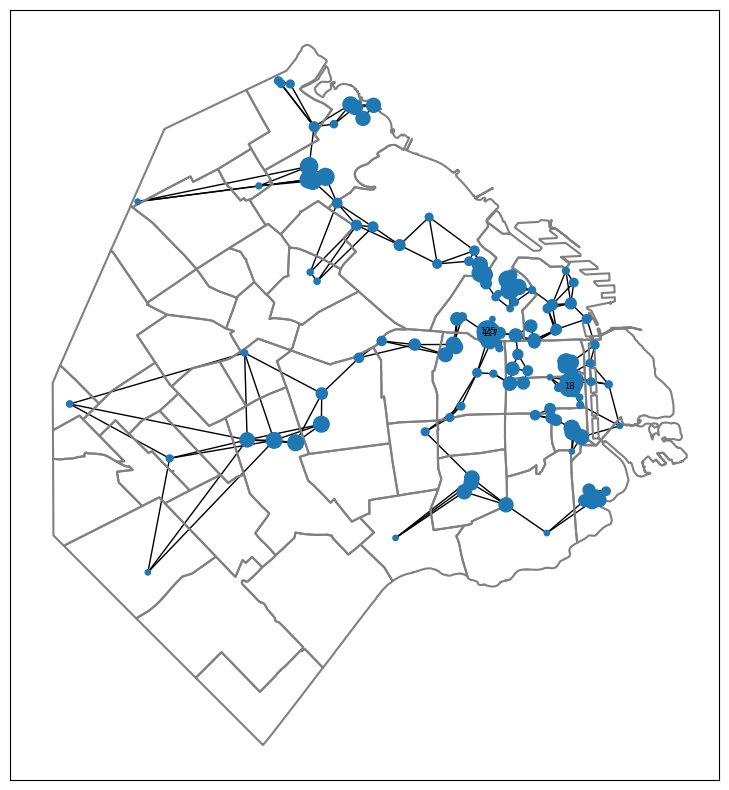

In [9]:
A = construye_adyacencia(D,3)

p = calcula_pagerank(A, 0.2)

GraficoCiudad(A, p, museos, barrios)

### Ranking con Diferente numero de Conexiones y mismo alpha (1/5)

Veamos como va evolucionando segun la diferente cantidad de conexiones, tomemos de caso base el anterior caso con 3 conexiones

In [10]:
conexiones = [1,3,5,10]

analisis = []

A = construye_adyacencia(D,3)

p = calcula_pagerank(A, 0.2)

principales = np.argsort(p)[0]

analizar = principales[np.arange(0,136,9)]

In [ ]:
principales = []
puntuaciones = []

for conexion in conexiones:
  A = construye_adyacencia(D,conexion)

  p = calcula_pagerank(A, 0.2)

  auxPrincipales = GraficoCiudad(A, p, museos, barrios)

  principales = np.concatenate((principales, auxPrincipales))

  p_norm = p/p.sum()

  puntuaciones.append(p_norm[0])

principales = np.array(list(set(principales)))

In [ ]:

for ciudad in principales:
  for i in range(4):
    analisis.append({"conexiones": conexiones[i], "ciudad": ciudad, "ranking" : puntuaciones[i][int(ciudad)]})


En esta seccion creamos un fráfico que muestra la variacion del page ranking de los 3 museos con mayor page ranking para las distintas cantiades de conexiones. Es decir, para algun numero de conexiones todos los museos que se muestran estuvieron en el top 3.

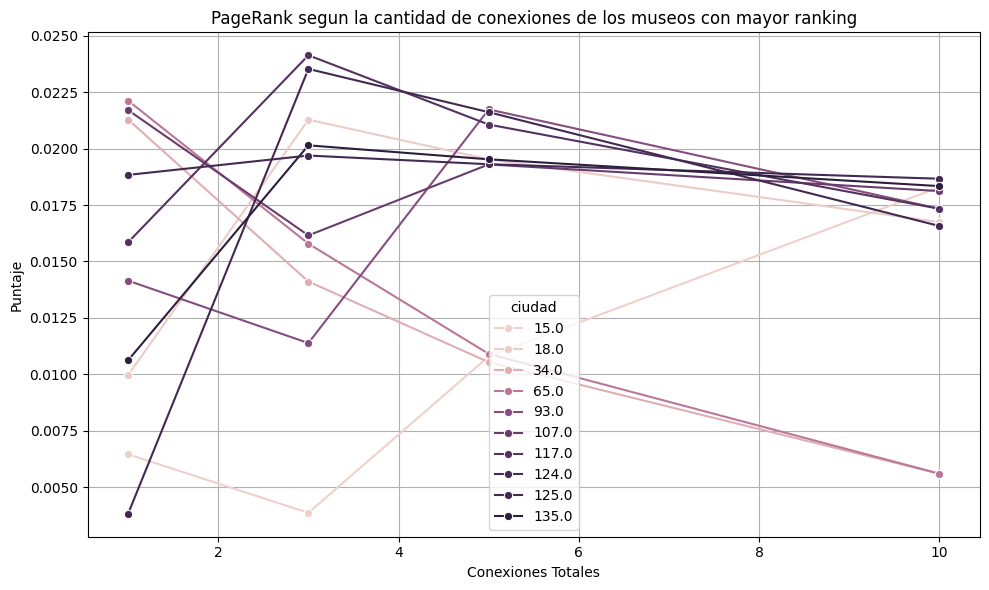

In [ ]:
df = pd.DataFrame(analisis)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="conexiones", y="ranking", hue="ciudad", marker="o", legend = "full")
plt.title("PageRank segun la cantidad de conexiones de los museos con mayor ranking")
plt.ylabel("Puntaje")
plt.xlabel("Conexiones Totales")
plt.grid(True)
plt.tight_layout()
plt.show()

Como se puede observar en el gráfico, los museos que se mantienen en el top del ranking, varían bastante.

Observaciones que nos gustaría destacar:

1) El top 1 y 3 cuando hay una sola conexión, son los que menor ranking tienen cuando hay más conexiones.

2) Los 3 últimos cuando hay una sola conexión, terminan estando cerca o en el top cuando hay más conexiones.

3) Los rankings están muy dispersos cuando hay pocas conexiones y tienden a agruparse mientras más conexiones hay.

#### Conclusiones:

Hay museos que son más relevantes mientras menores conexiones hay, que no lo son al aumentar las conexiones.

Hay museos que son irrelevantes con pocas conexiones pero muy relevantes al aumentarlas.

Con pocas conexiones, los puntajes de PageRank tienen una alta dispersión entre los museos, reflejando más variabilidad en la importancia de cada uno. A medida que el número de conexiones aumenta, los puntajes tienden a concentrarse, indicando una menor diferencia en la importancia de los museos dentro de la red.

También, observando los mapas que reflejan los pagerank de los museos, podemos visualizar la tendencia que tienen ciertas zonas de la ciudad a ser más o menos importantes. Los museos periféricos que podrían tener un pagerank elevado al haber pocas conexiones, pasan desapercibidos en el último mapa. Por el contrario, las zonas con mayor densidad de museos terminan siendo mucho más visibles.


### Ranking con 5 conexiones con diferentes alpha

Ahora si podemos ver como seria el ranking segun va cambiando el alpha que le asignemos, primero tomemos los 5 del Top y los 5 del Bottom del ranking para analizar mas tarde con alpha = 0,5

In [ ]:
A = construye_adyacencia(D,5)

Alphas = [1/7,1/5,1/3,1/2,2/3,4/5,6/7]

puntuaciones = []

analisisGeneral = []

analisisMaximos = []

# Primero vamos a tomar las ciudades 1 ciudad cada 9 para nuestro analisis]
p5 = calcula_pagerank(A, 0.5)

principales = np.argsort(p5)[0]

analizarGeneral = principales[np.arange(0,136,9)]

Ahora que tengo las ciudades que quiero guardar la puntuacion, veamos como quedan las ciudades armadas

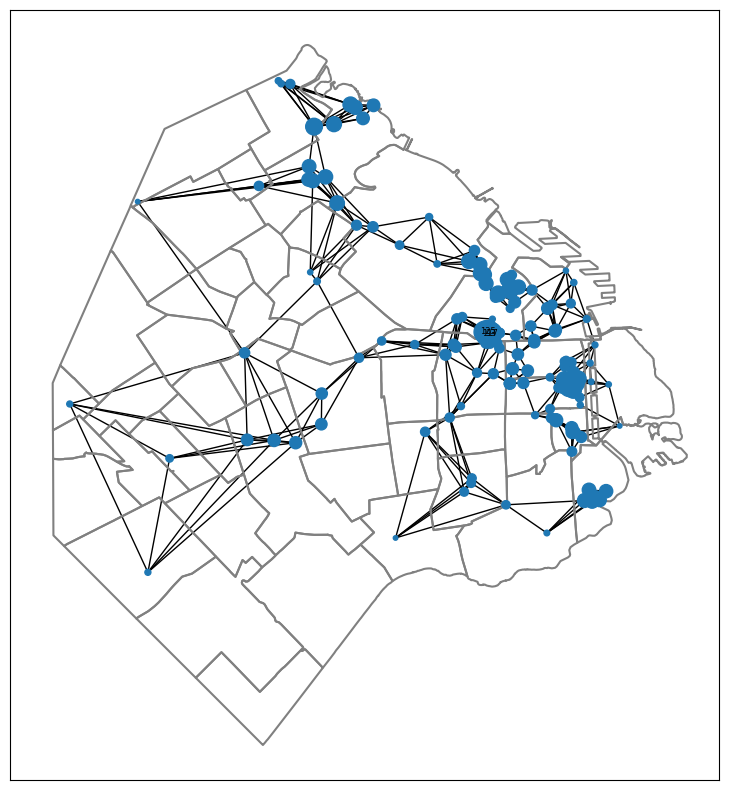

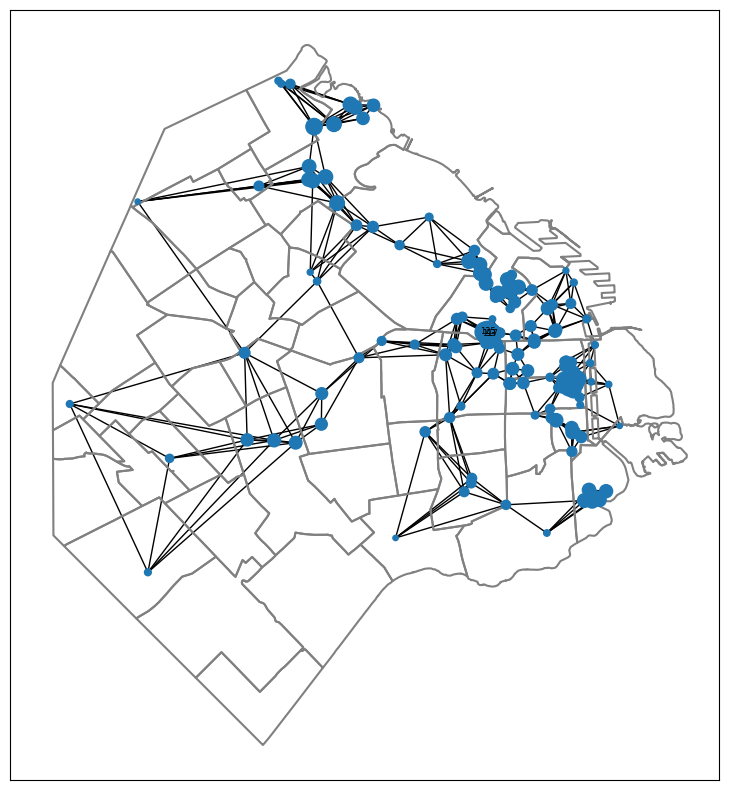

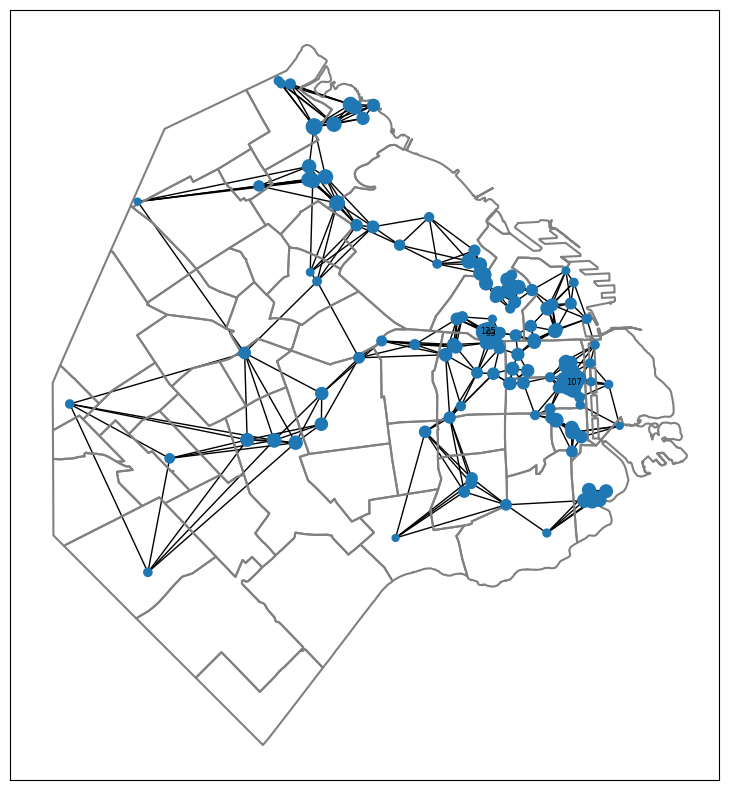

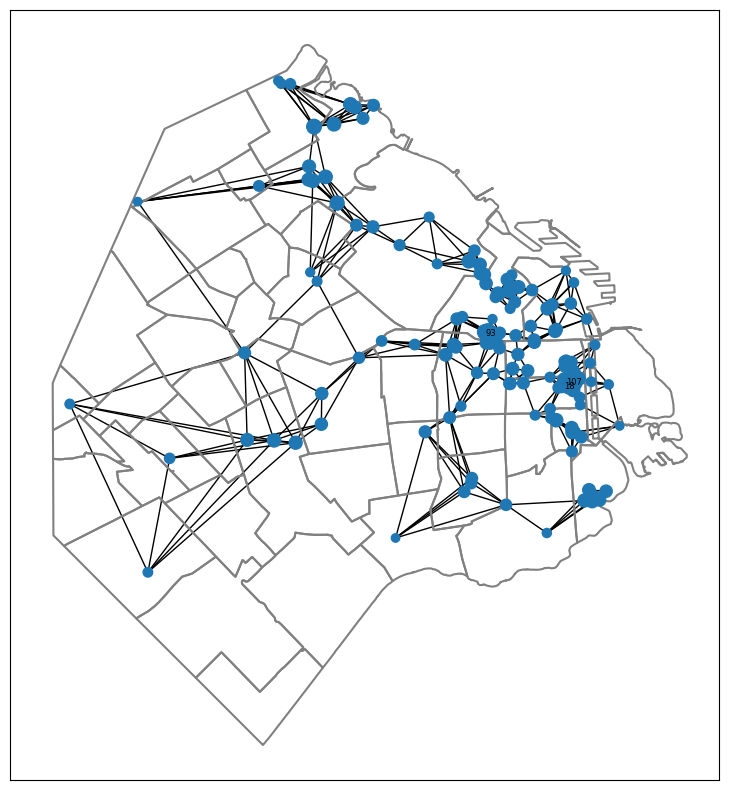

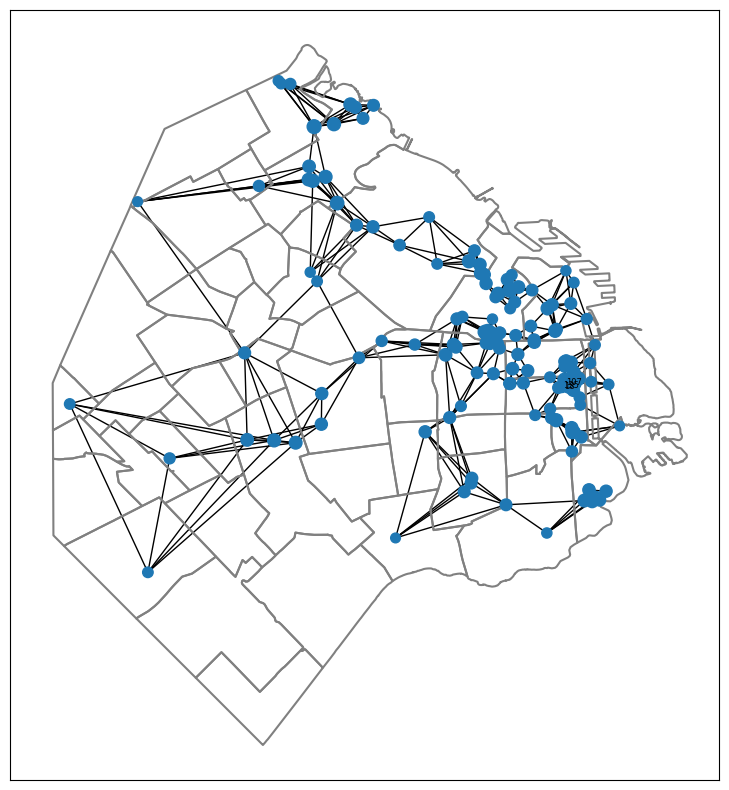

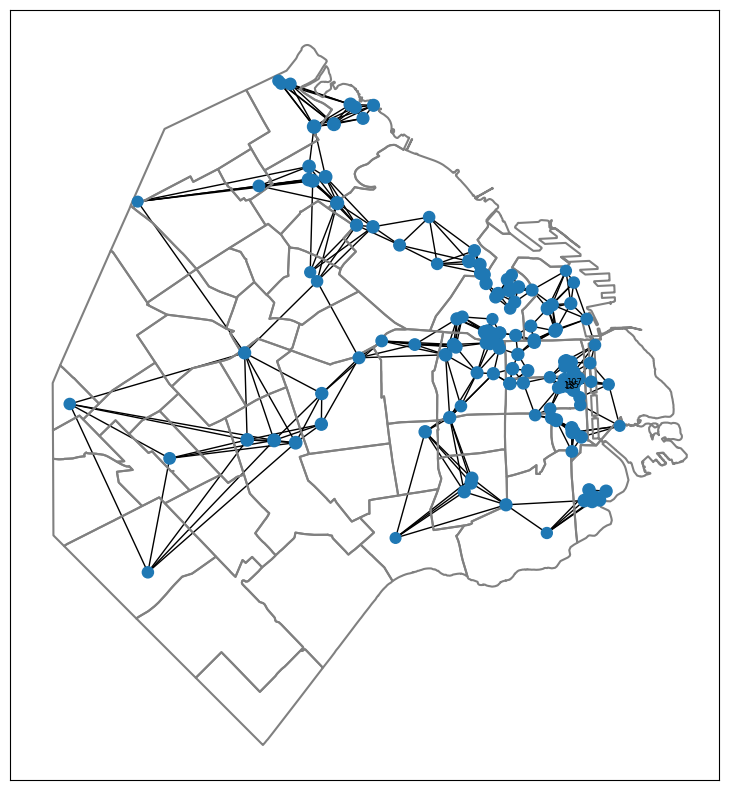

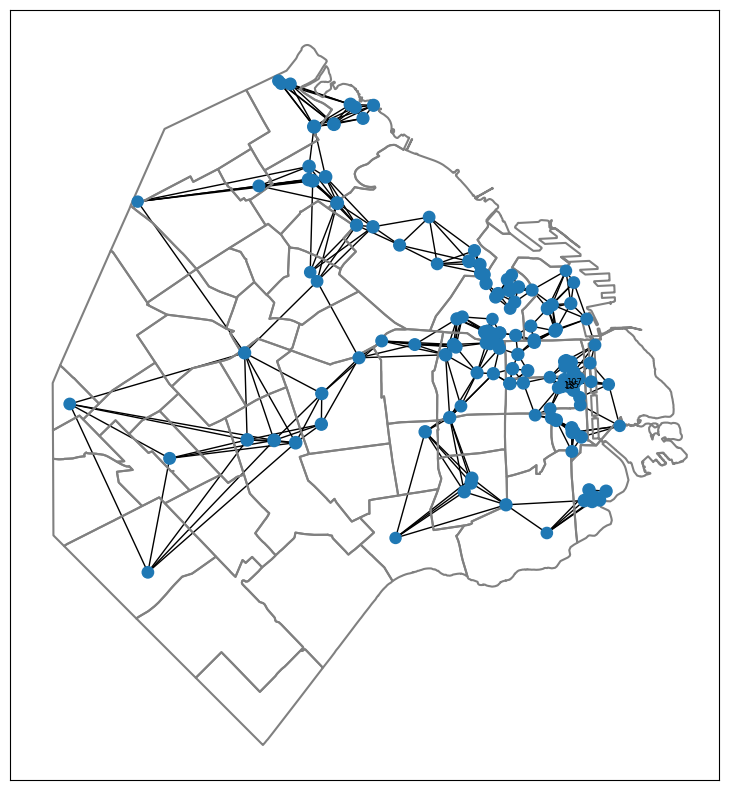

In [ ]:
for alpha in Alphas:
  p = calcula_pagerank(A, alpha)

  auxPrincipales = GraficoCiudad(A, p, museos, barrios)

  p_norm = p/p.sum()

  analisisMaximos = np.concat((analisisMaximos, auxPrincipales))

  puntuaciones.append(p_norm[0])

  for ciudad in analizar:
    analisis.append({"alpha": alpha, "ciudad": ciudad, "ranking": p_norm[0][ciudad]})


analisisMaximos = np.array(list(set(analisisMaximos)))

Ahora con las ciudades que elegimos, veamos como va evolucionando su ranking con los alphas, para esto con la informacion de las ciudades creamos un dataframe y usamos seaborn para el grafico

In [ ]:
df = pd.DataFrame(analisis)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="alpha", y="ranking", hue="ciudad", marker="o", legend = "full")
plt.title("PageRank para ciudades en general")
plt.ylabel("PageRank")
plt.xlabel("Alpha")
plt.grid(True)
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `alpha` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x600 with 0 Axes>

In [ ]:
analisis = []

for ciudad in analisisMaximos:
  for i in range(len(Alphas)):
    analisis.append({"alpha": Alphas[i], "ciudad": ciudad, "ranking" : puntuaciones[i][int(ciudad)]})


df = pd.DataFrame(analisis)

plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="alpha", y="ranking", hue="ciudad", marker="o", legend = "full")
plt.title("PageRank de los 3 Maximos en cada Alpha")
plt.ylabel("Puntuacion")
plt.xlabel("Alpha")
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'analisisMaximos' is not defined

#### Observaciones:

1) Todos los museos que están en el top, decrecen su ranking constantemente a medida que aumenta el alpha.

2) Los museos menos importantes aumentan su ranking constantemente.

3) La diferencia entre el mayor y menor ranking decrece constantemente.

#### Conclusiones:

Al aumentar el alpha, los museos tienden a tener un pagerank muy parecido. Esto genera que los museos periféricos tengan casi la misma importancia que los museos en áreas de alta densidad de museos. Por eso el tamaño de todos los nodos es casi idéntico en el último gráfico.


### Conclusiones generales
Al analizar ambas situaciones, el crecimiento de la cantidad de conexiones para un mismo alpha v.s. el crecimiento del alpha para una misma cantidad de conecciones:

Aumentar las conexiones genera museos con mucho ranking en las áreas de mayor densidad de museos, mientras que los más periféricos terminan siendo irrelevantes. Esta diferencia de ranking entre museos periféricos y centrales crece hasta que se estabiliza. Aumentar el alpha en cambio, hace lo contrario, aumenta el ranking de los más periféricos y reduce abruptamente el de los más centrales. Esto genera que la diferencia entre periféricos y centrales se achique muchísimo. Si bien sigue habiendo zonas con más importancia que otras, es por la densidad de museos y no por la presencia de museos con rankings muy altos.


## Punto 4:

Sabemos que
\begin{align}
 v_x &= C^{x} v_0 \\ &\Rightarrow C^{0} v_0  + C^{1} v_0 + C^{2} v_0 + ... +C^{r-1} v_0 \\ &= v_0 + v_1 + v_2 + ... + v_{r-1} = w
\end{align}

Es decir, $w$ es el vector con la cantidad total de personas que visitaban el museo despues de $r-1$ pasos

$\Rightarrow w = (\sum_{k=0}^{r-1} C^{k}) . v = B . v_0$

Si B es inversible, entonces vale que $v_0 = B^{-1} w$

Si B es inversible $\Rightarrow Bx = 0 \Leftrightarrow x = 0$

Supongo que existe $x \neq 0 \; tq \; Bx = 0$

$Bx = 0 \Leftrightarrow \sum_{k=0}^{r-1} C^{k} . x = 0 \Leftrightarrow C^{0} x  + C^{1} x + C^{2} x + ... +C^{r-1} x = 0$

Donde $(C^{k} x)_i = \sum_{j=0}^{r-1} C^{k}_{ij} . x_j$. Osea una combinacion lineal de $x$ con coeficientes positivos



*   Si $x \geq 0 \Rightarrow (C^{k} x)_i >0, \forall i \Rightarrow Bx = 0 \Leftrightarrow x=0 \; \underline{ABS!}$
*   Si:
\begin{align}
x < 0 &\Rightarrow llamemos \; x = x^{+} + x^{-} donde \; x^{+}, x^{-} > 0 \\ &\Rightarrow Bx = Bx^{+} - Bx^{-} \\ &\Rightarrow Bx = 0 \Leftrightarrow Bx^{+} = Bx^{-} \; \underline{OBS} \; Bx^{+} > 0, Bx^{-} > 0
\end{align}

Esto ocurre si solo si ambos $Bx$ son 0 $\rightarrow \underline{ABS!}$

Luego $Bx = 0 \Leftrightarrow x = \vec{0} \Rightarrow B$ es inversible

Luego vale que $v_0 = B^{-1} . w$



## Punto 5:

Primero lo que se nos pide es calcular nuestra nueva definicion de C la cual va a ser la siguiente

In [ ]:
C_continua = calcula_matriz_C_continua(D)

C_continua


array([[0.        , 0.00303675, 0.02011622, ..., 0.00826361, 0.00553176,
        0.0338589 ],
       [0.00119538, 0.        , 0.00129082, ..., 0.00237898, 0.00660921,
        0.00093357],
       [0.0192172 , 0.00313266, 0.        , ..., 0.01092125, 0.00541689,
        0.01531572],
       ...,
       [0.00468455, 0.00342604, 0.00648077, ..., 0.        , 0.0050311 ,
        0.00378953],
       [0.00122469, 0.00371719, 0.00125536, ..., 0.00196484, 0.        ,
        0.00094881],
       [0.04248399, 0.0029758 , 0.02011622, ..., 0.00838763, 0.00537734,
        0.        ]])

Una vez que tenemos nuestra nueva C, la podemos usar para calcular nuestro B la cual esta definida como $B = \sum_{k=0}^{r-1}{C^{k}}$, en este caso vamos a usar r = 3

In [ ]:
r = 3

B = calcula_B(C_continua, r)

B

array([[1.02830029, 0.00906477, 0.03712002, ..., 0.01871298, 0.01398526,
        0.05859437],
       [0.00356823, 1.06582312, 0.0037657 , ..., 0.00593181, 0.01377948,
        0.00300604],
       [0.03546106, 0.0091389 , 1.02451984, ..., 0.02212063, 0.01354249,
        0.03202599],
       ...,
       [0.01060818, 0.00854258, 0.01312658, ..., 1.00997131, 0.01094079,
        0.00938005],
       [0.00309622, 0.00774994, 0.00313846, ..., 0.0042728 , 1.00927891,
        0.00262936],
       [0.07352048, 0.00958189, 0.04206409, ..., 0.02076154, 0.01490187,
        1.05762105]])

Ahora si con todo podemos calcular el vector v final usando nuestro vector de visitas y la B calculada antes

In [ ]:
w = np.loadtxt("visitas.txt")

w

FileNotFoundError: visitas.txt not found.

In [ ]:
v = Calcular_v(B,w)

v

Podemos ver como quedaria las puntuaciones con el grafico de la ciudad, donde el tamaño de los nodos representa la puntuacion

In [ ]:
np.array([[0,1]]).shape



In [ ]:
GraficoCiudad(A, v, museos, barrios)

In [ ]:
print("Finalmente nuestra Norma 1 de V es: " + str(int(sum(v))))

## Punto 6:

En este punto vamos a calcular el Numero de condicion de Nuestro B del punto anterior y con este calcular la cota superior de error de las visitas calculada

In [ ]:
print("Numero de Condicion 1 de B: " + str(NumCond1_Matriz(B)))

NameError: name 'B' is not defined

In [ ]:
print("La cota superior es: " + str(NumCond1_Matriz(B) * 0.05 * 100) + "% de Error")

NameError: name 'B' is not defined

# Extras

Para graficar la red con un conjunto de puntajes (como el Page Rank)

In [ ]:
factor_escala = 1e4 # Escalamos los nodos 10 mil veces para que sean bien visibles
fig, ax = plt.subplots(figsize=(10, 10)) # Visualización de la red en el mapa
barrios.to_crs("EPSG:22184").boundary.plot(color='gray',ax=ax) # Graficamos Los barrios
pr = np.random.uniform(0,1,museos.shape[0])# Este va a ser su score Page Rank. Ahora lo reemplazamos con un vector al azar
pr = pr/pr.sum() # Normalizamos para que sume 1
Nprincipales = 5 # Cantidad de principales
principales = np.argsort(pr)[-Nprincipales:] # Identificamos a los N principales
labels = {n: str(n) if i in principales else "" for i, n in enumerate(G.nodes)} # Nombres para esos nodos
nx.draw_networkx(G,G_layout,node_size = pr*factor_escala, ax=ax,with_labels=False) # Graficamos red
nx.draw_networkx_labels(G, G_layout, labels=labels, font_size=6, font_color="k") # Agregamos los nombres